# Dataset Exploration

This notebook explores the PlantVillage dataset, which contains 10 disease classes organized in one folder per class.

In [2]:
import os
from pathlib import Path
import yaml

# Move up two levels: notebooks/ -> preprocessing/ -> repo root
os.chdir(Path.cwd().parents[1])

config_path = Path("configs/default.yaml")

with config_path.open("r", encoding="utf-8") as handle:
    config = yaml.safe_load(handle) or {}

raw_dataset_path = config.get("data", {}).get("raw_dir", "data/raw/plantvillage")
image_size = config.get("data", {}).get("image_size", 256)

print(f"Raw dataset path : {raw_dataset_path}")
print(f"Image size       : {image_size}")

Raw dataset path : data/raw/plantvillage
Image size       : 256


In [3]:
from pathlib import Path

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp", ".tif", ".tiff"}
dataset_dir = Path.cwd() / "data" / "raw" / "plantvillage"

rows = []
for class_dir in sorted(dataset_dir.iterdir()):
    if not class_dir.is_dir():
        continue
    image_count = sum(1 for file_path in class_dir.iterdir() if file_path.is_file() and file_path.suffix.lower() in image_extensions)
    rows.append((class_dir.name, image_count))

print(f"{'Class name':<35} {'Image count':>12} Status")
print(f"{'-' * 35} {'-' * 12} {'-' * 30}")
for class_name, image_count in rows:
    status = "WARNING: low sample count" if image_count < 200 else ""
    print(f"{class_name:<35} {image_count:>12} {status}")

Class name                           Image count Status
----------------------------------- ------------ ------------------------------
Tomato___Bacterial_spot                     1702 
Tomato___Early_blight                        800 
Tomato___Late_blight                        1527 
Tomato___Leaf_Mold                           761 
Tomato___Septoria_leaf_spot                 1417 
Tomato___Spider_mites Two-spotted_spider_mite         1341 
Tomato___Target_Spot                        1123 
Tomato___Tomato_Yellow_Leaf_Curl_Virus         4286 
Tomato___Tomato_mosaic_virus                 299 
Tomato___healthy                            1273 


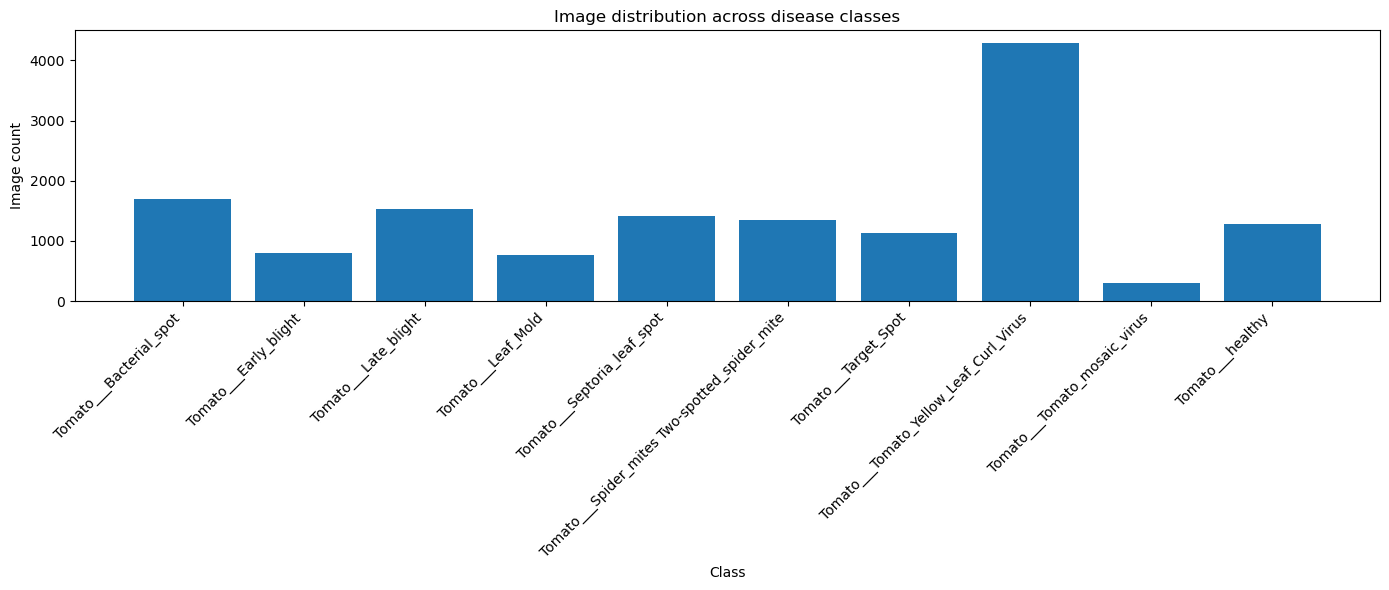

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp", ".tif", ".tiff"}
dataset_dir = Path.cwd() / "data" / "raw" / "plantvillage"
docs_dir = Path.cwd() / "docs"
docs_dir.mkdir(exist_ok=True)

class_names = []
image_counts = []
for class_dir in sorted(dataset_dir.iterdir()):
    if not class_dir.is_dir():
        continue
    class_names.append(class_dir.name)
    image_counts.append(sum(1 for file_path in class_dir.iterdir() if file_path.is_file() and file_path.suffix.lower() in image_extensions))

plt.figure(figsize=(14, 6))
plt.bar(class_names, image_counts)
plt.title("Image distribution across disease classes")
plt.xlabel("Class")
plt.ylabel("Image count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(docs_dir / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

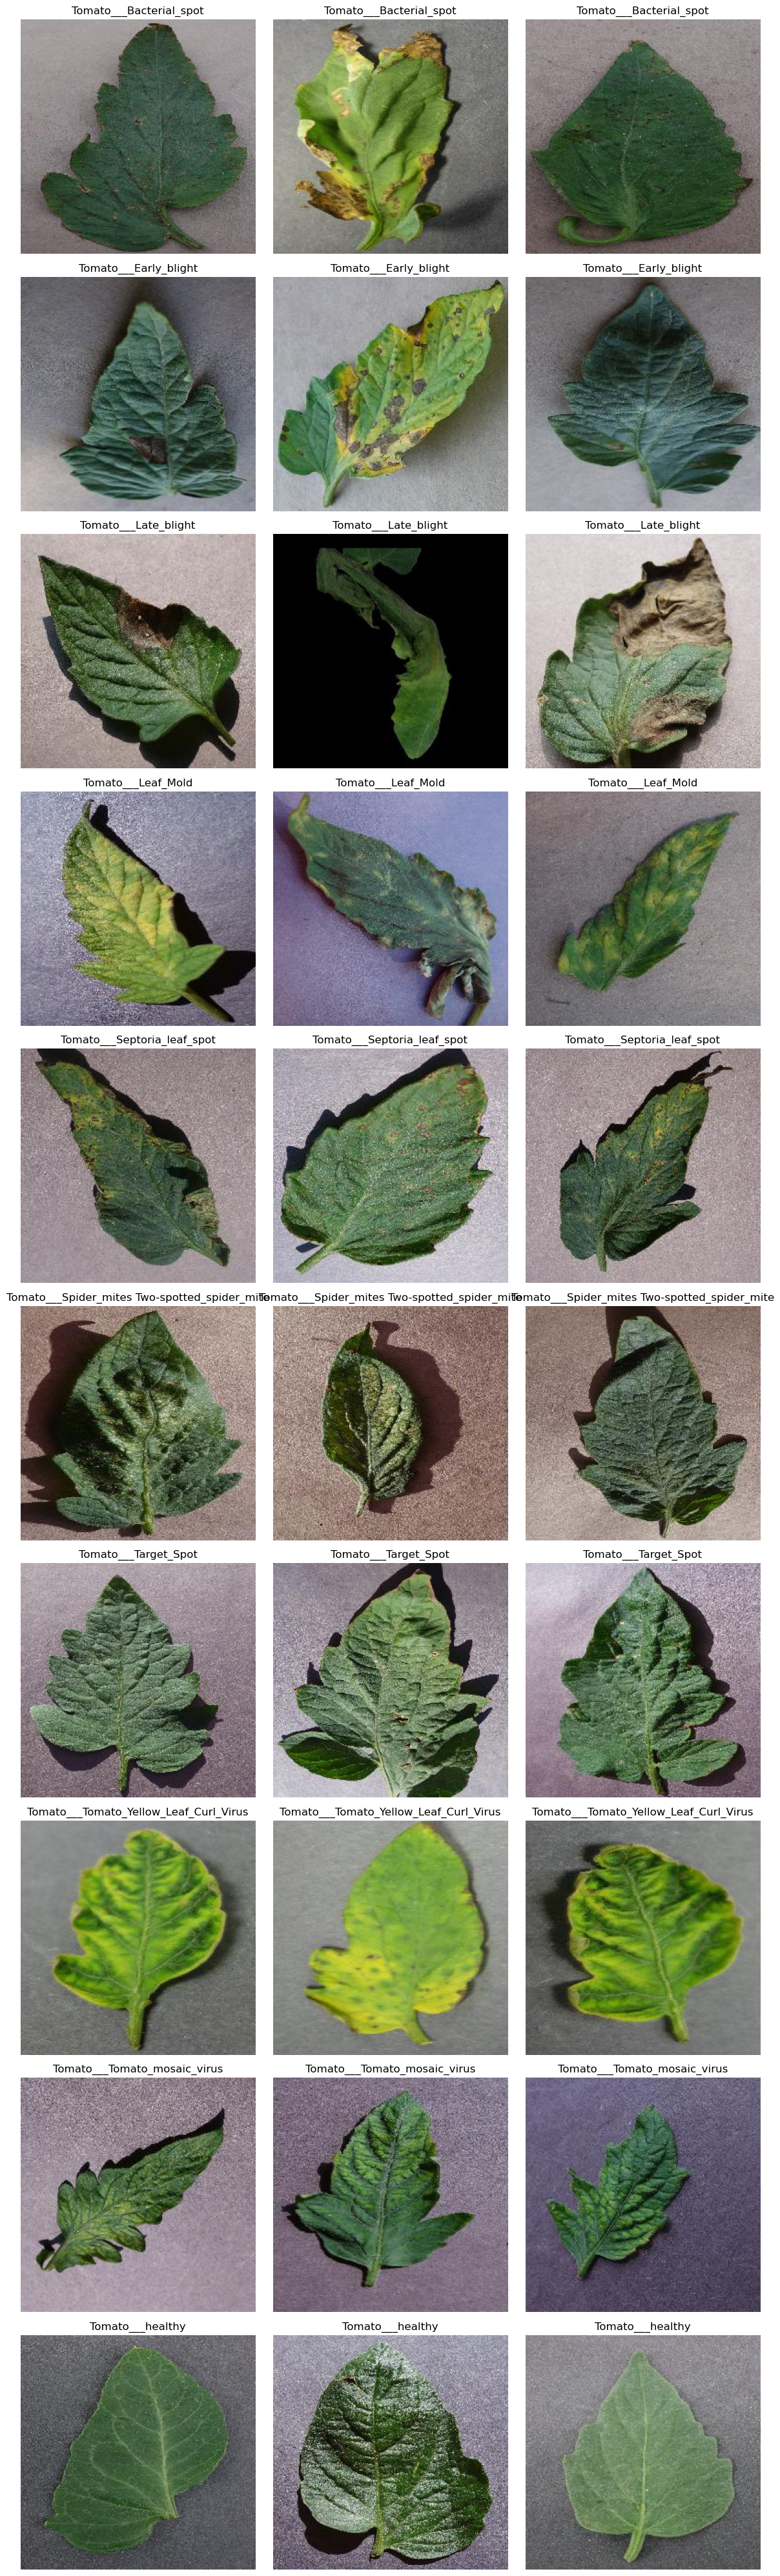

In [5]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
from PIL import Image

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp", ".tif", ".tiff"}
dataset_dir = Path.cwd() / "data" / "raw" / "plantvillage"

class_dirs = [class_dir for class_dir in sorted(dataset_dir.iterdir()) if class_dir.is_dir()]
fig, axes = plt.subplots(len(class_dirs), 3, figsize=(12, 4 * max(len(class_dirs), 1)))
if len(class_dirs) == 1:
    axes = [axes]

for row_index, class_dir in enumerate(class_dirs):
    image_paths = [file_path for file_path in class_dir.iterdir() if file_path.is_file() and file_path.suffix.lower() in image_extensions]
    selected_paths = random.sample(image_paths, k=min(3, len(image_paths)))
    row_axes = axes[row_index]
    if not isinstance(row_axes, (list, tuple)):
        row_axes = list(row_axes)

    for col_index in range(3):
        ax = row_axes[col_index]
        ax.axis("off")
        if col_index >= len(selected_paths):
            continue
        image_path = selected_paths[col_index]
        with Image.open(image_path) as image:
            ax.imshow(image.convert("RGB"))
        ax.set_title(class_dir.name)

plt.tight_layout()
plt.show()

In [6]:
from pathlib import Path
import random

from PIL import Image

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp", ".tif", ".tiff"}
dataset_dir = Path.cwd() / "data" / "raw" / "plantvillage"

all_image_paths = []
for class_dir in sorted(dataset_dir.iterdir()):
    if not class_dir.is_dir():
        continue
    all_image_paths.extend(
        file_path for file_path in class_dir.iterdir() if file_path.is_file() and file_path.suffix.lower() in image_extensions
    )

selected_paths = random.sample(all_image_paths, k=min(5, len(all_image_paths)))
image_sizes = []
for image_path in selected_paths:
    with Image.open(image_path) as image:
        size = image.size
    image_sizes.append(size)
    print(f"{image_path.name}: {size[0]} x {size[1]}")

unique_sizes = sorted(set(image_sizes))
if len(unique_sizes) == 1:
    print("All images are the same size")
else:
    print(f"Unique sizes found: {unique_sizes}")

cf7105a7-3ba3-4676-af9b-131e89655464___UF.GRC_YLCV_Lab 03318.JPG: 256 x 256
74e2dac2-ae38-4349-8d26-7e694fdad667___RS_Late.B 5185.JPG: 256 x 256
659908ff-205b-4fd1-af8b-5b2c11b56adf___GCREC_Bact.Sp 3139.JPG: 256 x 256
78522b1b-254b-4ffc-95c8-cb3240f5d8d6___YLCV_NREC 2360.JPG: 256 x 256
efd88799-7fbc-4638-b66b-4e49c7bf7b9f___RS_Erly.B 9390.JPG: 256 x 256
All images are the same size
